# 🍸 Difford's Guide 調酒資料庫詳細分析

這個 notebook 提供完整的調酒資料分析，包括：
- 基本統計與 Unique Items 分析
- 評分系統視覺化
- 風味檔案分析
- 難度與複雜度分析
- 營養與酒精指標
- 分類、標籤、材料分析

## 0. 環境設定與套件載入

In [1]:
# 安裝必要套件（首次執行時取消註解）
# !pip install pymongo pandas matplotlib seaborn plotly wordcloud python-dotenv nbformat

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud
from pymongo import MongoClient
from collections import Counter
from dotenv import load_dotenv
import os
import warnings

warnings.filterwarnings('ignore')
load_dotenv()

# 設定視覺化風格
sns.set_style('whitegrid')
sns.set_palette('husl')

# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("✅ 套件載入完成")

✅ 套件載入完成


## 1. 資料載入

In [3]:
# 連接 MongoDB
MONGO_URI = os.getenv('MONGO_URI', 'mongodb://localhost:27017/')
DB_NAME = os.getenv('MONGO_DB_NAME', 'cocktail_ai')

client = MongoClient(MONGO_URI)
db = client[DB_NAME]

# 載入所有調酒資料
cocktails = list(db.cocktails.find({}))

print(f"✅ 成功載入 {len(cocktails)} 款調酒")
print(f"\n資料庫: {DB_NAME}")
print(f"Collection: cocktails")

✅ 成功載入 6659 款調酒

資料庫: cocktail_ai
Collection: cocktails


## 2. 基本統計與 Unique Items 分析

In [4]:
# 計算各項 unique 數量
total_cocktails = len(cocktails)

# Unique 分類
unique_categories = set(c.get('category') for c in cocktails if c.get('category'))
print(f"📊 Unique 分類數量: {len(unique_categories)}")

# Unique 杯具
unique_glasses = set(c.get('glass') for c in cocktails if c.get('glass'))
print(f"🥃 Unique 杯具種類: {len(unique_glasses)}")

# Unique 標籤
all_tags = []
for c in cocktails:
    if c.get('tags'):
        all_tags.extend(c['tags'])
unique_tags = set(all_tags)
print(f"🏷️  Unique 標籤數量: {len(unique_tags)}")
print(f"   總標籤使用次數: {len(all_tags)}")

# Unique 材料
all_ingredients = []
for c in cocktails:
    if c.get('ingredients'):
        all_ingredients.extend([ing.lower() for ing in c['ingredients']])
unique_ingredients = set(all_ingredients)
print(f"🌿 Unique 材料數量: {len(unique_ingredients)}")
print(f"   總材料使用次數: {len(all_ingredients)}")

# 難度分布
difficulty_counts = Counter(c.get('difficulty') for c in cocktails if c.get('difficulty'))
print(f"\n💪 難度分布:")
for difficulty in ['easy', 'medium', 'hard']:
    count = difficulty_counts.get(difficulty, 0)
    percentage = count / total_cocktails * 100
    print(f"   {difficulty:8s}: {count:4d} ({percentage:5.1f}%)")

# 資料完整度
completeness = {
    '評分': sum(1 for c in cocktails if c.get('ratings')),
    '風味檔案': sum(1 for c in cocktails if c.get('taste_profile')),
    '營養資訊': sum(1 for c in cocktails if c.get('nutrition')),
    '酒精指標': sum(1 for c in cocktails if c.get('alcohol_metrics')),
    '歷史故事': sum(1 for c in cocktails if c.get('history')),
    '專業評論': sum(1 for c in cocktails if c.get('review')),
    '杯具': sum(1 for c in cocktails if c.get('glass')),
    '難度': sum(1 for c in cocktails if c.get('difficulty')),
}

print(f"\n📋 資料完整度:")
for field, count in completeness.items():
    percentage = count / total_cocktails * 100
    print(f"   {field:8s}: {count:4d} ({percentage:5.1f}%)")

📊 Unique 分類數量: 17
🥃 Unique 杯具種類: 203
🏷️  Unique 標籤數量: 15
   總標籤使用次數: 12807
🌿 Unique 材料數量: 943
   總材料使用次數: 31010

💪 難度分布:
   easy    :  304 (  4.6%)
   medium  : 4590 ( 68.9%)
   hard    : 1765 ( 26.5%)

📋 資料完整度:
   評分      : 6659 (100.0%)
   風味檔案    : 6659 (100.0%)
   營養資訊    : 6659 (100.0%)
   酒精指標    : 6659 (100.0%)
   歷史故事    : 5610 ( 84.2%)
   專業評論    : 6466 ( 97.1%)
   杯具      : 6659 (100.0%)
   難度      : 6659 (100.0%)


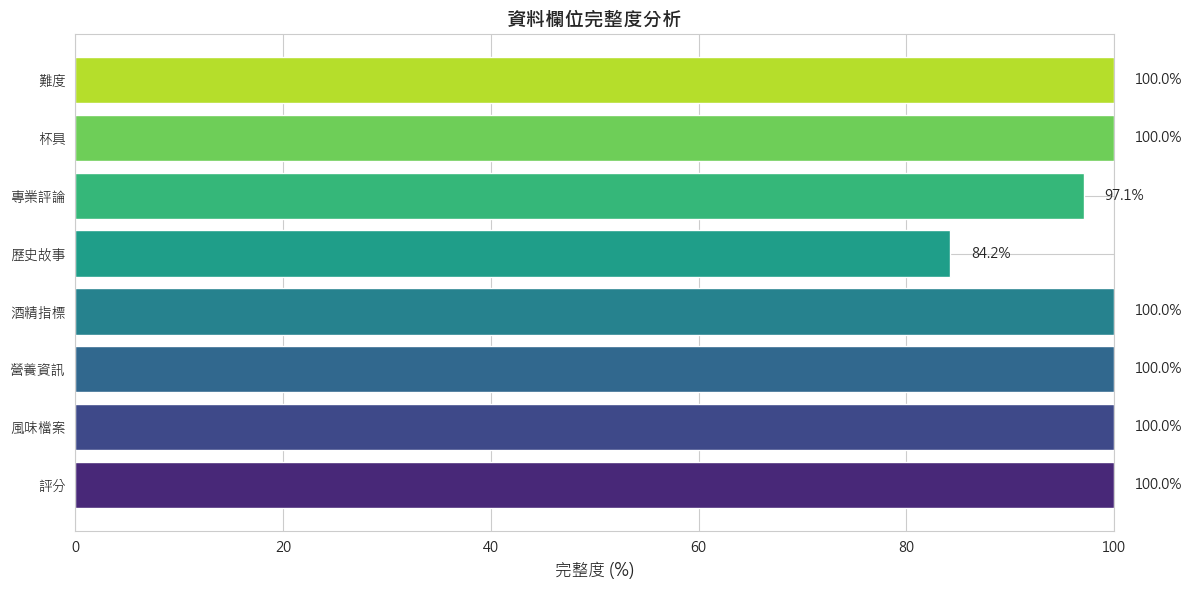

In [5]:
# 視覺化：資料完整度
fig, ax = plt.subplots(figsize=(12, 6))

fields = list(completeness.keys())
percentages = [completeness[f] / total_cocktails * 100 for f in fields]

bars = ax.barh(fields, percentages, color=sns.color_palette('viridis', len(fields)))
ax.set_xlabel('完整度 (%)', fontsize=12)
ax.set_title('資料欄位完整度分析', fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)

# 添加數值標籤
for i, (bar, pct) in enumerate(zip(bars, percentages)):
    ax.text(pct + 2, bar.get_y() + bar.get_height()/2, 
            f'{pct:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [6]:
# 詳細欄位缺失值分析
print("="*80)
print("📋 詳細欄位缺失值分析")
print("="*80)

field_analysis = {}

# 分析各個重要欄位
fields_to_analyze = {
    'method_sections': ('製作步驟（結構化）', lambda c: not c.get('method_sections') or len(c.get('method_sections', [])) == 0),
    'method': ('製作步驟（簡單）', lambda c: not c.get('method') or len(c.get('method', [])) == 0),
    'review': ('專業評論', lambda c: not c.get('review') or len(c.get('review', [])) == 0),
    'history': ('歷史故事', lambda c: not c.get('history') or len(c.get('history', [])) == 0),
    'cotd': ('每日精選資訊', lambda c: not c.get('cotd') or not c.get('cotd', {}).get('text')),
    'ratings.professional': ('專業評分', lambda c: c.get('ratings', {}).get('professional') is None),
    'ratings.public': ('公眾評分', lambda c: c.get('ratings', {}).get('public') is None),
    'ratings.public_count': ('公眾評分次數', lambda c: not c.get('ratings', {}).get('public_count')),
    'taste_profile.strength': ('酒精強度', lambda c: c.get('taste_profile', {}).get('strength') is None),
    'taste_profile.sweetness': ('甜度', lambda c: c.get('taste_profile', {}).get('sweetness') is None),
    'nutrition.calories': ('卡路里資訊', lambda c: c.get('nutrition', {}).get('calories') is None),
    'alcohol_metrics.abv': ('酒精濃度 ABV', lambda c: c.get('alcohol_metrics', {}).get('abv') is None),
    'alcohol_metrics.standard_drinks': ('標準飲酒量', lambda c: c.get('alcohol_metrics', {}).get('standard_drinks') is None),
    'variants': ('變化版本', lambda c: not c.get('variants') or len(c.get('variants', [])) == 0),
    'allergens': ('過敏原資訊', lambda c: not c.get('allergens') or len(c.get('allergens', [])) == 0),
    'ingredients_detail': ('詳細材料配方', lambda c: not c.get('ingredients_detail') or len(c.get('ingredients_detail', [])) == 0),
    'image_url': ('調酒圖片', lambda c: not c.get('image_url') and not c.get('image')),
    'glass': ('杯具', lambda c: not c.get('glass'))
}

for field_key, (field_name, check_func) in fields_to_analyze.items():
    missing_count = sum(1 for c in cocktails if check_func(c))
    present_count = total_cocktails - missing_count
    missing_pct = (missing_count / total_cocktails * 100)
    present_pct = (present_count / total_cocktails * 100)
    
    field_analysis[field_key] = {
        'name': field_name,
        'missing': missing_count,
        'present': present_count,
        'missing_pct': missing_pct,
        'present_pct': present_pct
    }

# 按缺失百分比排序
sorted_fields = sorted(field_analysis.items(), key=lambda x: x[1]['missing_pct'], reverse=True)

print(f"\n{'欄位名稱':<25} {'缺失數量':>10} {'缺失率':>10} {'完整數量':>10} {'完整率':>10}")
print("-"*80)

for field_key, data in sorted_fields:
    status = "❌" if data['missing_pct'] > 50 else "⚠️" if data['missing_pct'] > 20 else "✅"
    print(f"{status} {data['name']:<23} {data['missing']:>9} {data['missing_pct']:>9.1f}% {data['present']:>9} {data['present_pct']:>9.1f}%")

print("\n" + "="*80)
print(f"總結: {len([f for f in field_analysis.values() if f['present_pct'] >= 80])} 個欄位完整率 ≥80%")
print(f"      {len([f for f in field_analysis.values() if f['present_pct'] < 80])} 個欄位完整率 <80%")
print("="*80)

📋 詳細欄位缺失值分析

欄位名稱                            缺失數量        缺失率       完整數量        完整率
--------------------------------------------------------------------------------
❌ 每日精選資訊                       6343      95.3%       316       4.7%
❌ 變化版本                         5596      84.0%      1063      16.0%
❌ 過敏原資訊                        3538      53.1%      3121      46.9%
⚠️ 甜度                           2052      30.8%      4607      69.2%
⚠️ 酒精強度                         1998      30.0%      4661      70.0%
⚠️ 卡路里資訊                        1404      21.1%      5255      78.9%
✅ 標準飲酒量                        1107      16.6%      5552      83.4%
✅ 歷史故事                         1049      15.8%      5610      84.2%
✅ 酒精濃度 ABV                     1041      15.6%      5618      84.4%
✅ 專業評論                          193       2.9%      6466      97.1%
✅ 專業評分                          183       2.7%      6476      97.3%
✅ 公眾評分                           14       0.2%      6645      99.8%
✅ 公眾評分次數         

## 3. 綜合缺失值分析

深入分析各欄位的資料完整度，找出資料缺失的模式和潛在問題。

## 3. 評分系統分析

In [7]:
# 提取評分資料
professional_ratings = []
public_ratings = []
cocktail_names = []

for c in cocktails:
    if c.get('ratings'):
        if c['ratings'].get('professional'):
            professional_ratings.append(c['ratings']['professional'])
            cocktail_names.append(c.get('name', 'Unknown'))
        if c['ratings'].get('public'):
            public_ratings.append(c['ratings']['public'])

print(f"專業評分數量: {len(professional_ratings)}")
print(f"公眾評分數量: {len(public_ratings)}")

if professional_ratings:
    print(f"\n專業評分統計:")
    print(f"  平均: {np.mean(professional_ratings):.2f}")
    print(f"  中位數: {np.median(professional_ratings):.2f}")
    print(f"  標準差: {np.std(professional_ratings):.2f}")
    print(f"  最高: {np.max(professional_ratings):.2f}")
    print(f"  最低: {np.min(professional_ratings):.2f}")

專業評分數量: 6476
公眾評分數量: 6645

專業評分統計:
  平均: 4.14
  中位數: 4.00
  標準差: 0.47
  最高: 5.50
  最低: 1.50


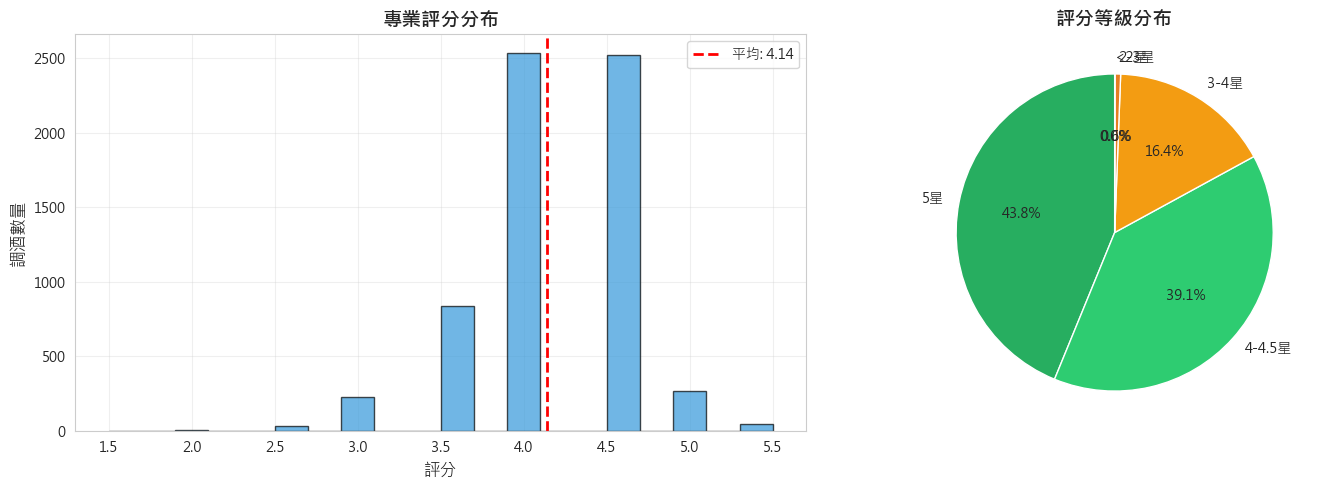

In [8]:
# 視覺化：評分分布
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 專業評分分布
if professional_ratings:
    axes[0].hist(professional_ratings, bins=20, color='#3498db', alpha=0.7, edgecolor='black')
    axes[0].axvline(np.mean(professional_ratings), color='red', linestyle='--', linewidth=2, label=f'平均: {np.mean(professional_ratings):.2f}')
    axes[0].set_xlabel('評分', fontsize=12)
    axes[0].set_ylabel('調酒數量', fontsize=12)
    axes[0].set_title('專業評分分布', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# 評分分類統計
rating_categories = {
    '5星': sum(1 for r in professional_ratings if r >= 4.5),
    '4-4.5星': sum(1 for r in professional_ratings if 4 <= r < 4.5),
    '3-4星': sum(1 for r in professional_ratings if 3 <= r < 4),
    '2-3星': sum(1 for r in professional_ratings if 2 <= r < 3),
    '<2星': sum(1 for r in professional_ratings if r < 2),
}

colors = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
axes[1].pie(rating_categories.values(), labels=rating_categories.keys(), autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('評分等級分布', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

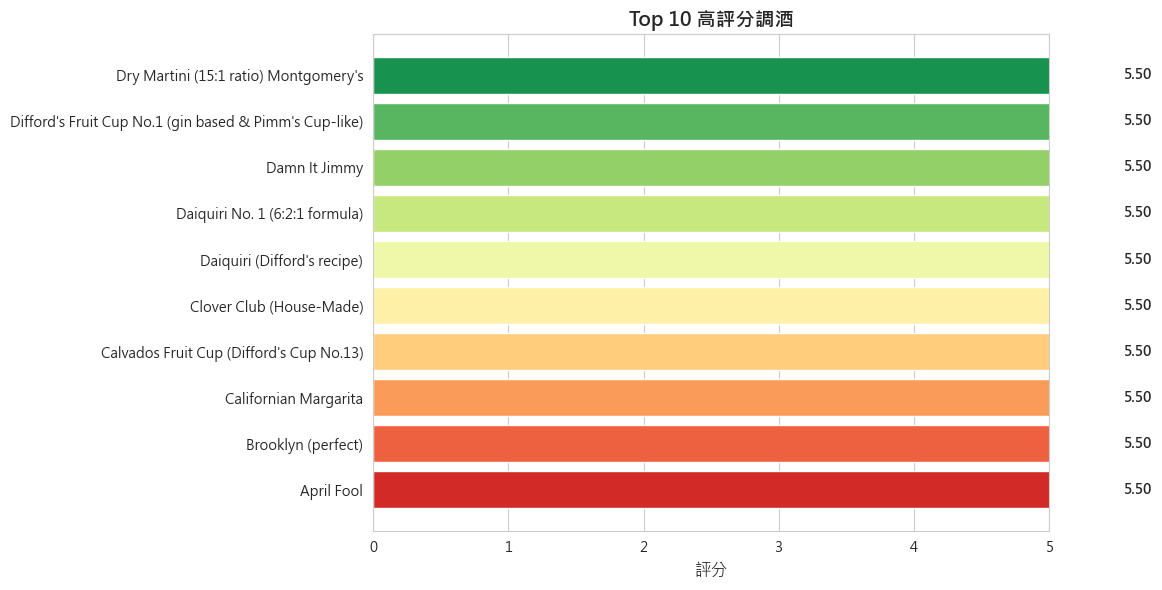

In [9]:
# Top 10 高評分調酒
if professional_ratings:
    rating_df = pd.DataFrame({
        'name': cocktail_names[:len(professional_ratings)],
        'rating': professional_ratings
    })
    top_10 = rating_df.nlargest(10, 'rating')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(range(10), top_10['rating'].values, color=sns.color_palette('RdYlGn', 10))
    ax.set_yticks(range(10))
    ax.set_yticklabels(top_10['name'].values)
    ax.set_xlabel('評分', fontsize=12)
    ax.set_title('Top 10 高評分調酒', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 5)
    
    for i, (bar, rating) in enumerate(zip(bars, top_10['rating'].values)):
        ax.text(rating + 0.05, bar.get_y() + bar.get_height()/2, 
                f'{rating:.2f}', va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 4. 風味檔案分析

In [10]:
# 提取風味資料
strength_values = []
sweetness_values = []
flavor_cocktails = []

for c in cocktails:
    if c.get('taste_profile'):
        tp = c['taste_profile']
        if tp.get('strength') is not None and tp.get('sweetness') is not None:
            strength_values.append(tp['strength'])
            sweetness_values.append(tp['sweetness'])
            flavor_cocktails.append(c.get('name', 'Unknown'))

print(f"有完整風味檔案的調酒: {len(strength_values)}")
if strength_values:
    print(f"\n酒精強度統計:")
    print(f"  平均: {np.mean(strength_values):.2f}")
    print(f"  中位數: {np.median(strength_values):.2f}")
    print(f"\n甜度統計:")
    print(f"  平均: {np.mean(sweetness_values):.2f}")
    print(f"  中位數: {np.median(sweetness_values):.2f}")

有完整風味檔案的調酒: 4607

酒精強度統計:
  平均: 6.82
  中位數: 7.00

甜度統計:
  平均: 6.40
  中位數: 6.00


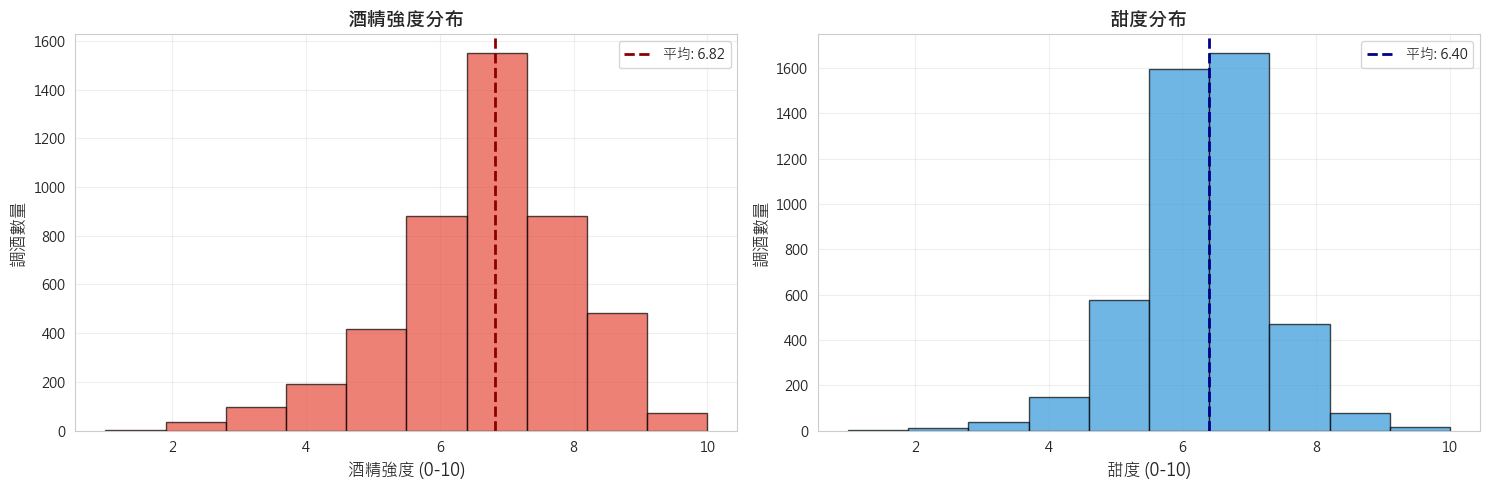

In [11]:
# 視覺化：風味分布
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 酒精強度分布
if strength_values:
    axes[0].hist(strength_values, bins=10, color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[0].axvline(np.mean(strength_values), color='darkred', linestyle='--', linewidth=2, label=f'平均: {np.mean(strength_values):.2f}')
    axes[0].set_xlabel('酒精強度 (0-10)', fontsize=12)
    axes[0].set_ylabel('調酒數量', fontsize=12)
    axes[0].set_title('酒精強度分布', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# 甜度分布
if sweetness_values:
    axes[1].hist(sweetness_values, bins=10, color='#3498db', alpha=0.7, edgecolor='black')
    axes[1].axvline(np.mean(sweetness_values), color='darkblue', linestyle='--', linewidth=2, label=f'平均: {np.mean(sweetness_values):.2f}')
    axes[1].set_xlabel('甜度 (0-10)', fontsize=12)
    axes[1].set_ylabel('調酒數量', fontsize=12)
    axes[1].set_title('甜度分布', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# 互動式氣泡圖：強度 vs 甜度（氣泡大小代表調酒數量）
if strength_values and sweetness_values:
    # 準備資料 - 先收集所有調酒的風味資料
    flavor_data = []
    for c in cocktails:
        tp = c.get('taste_profile', {})
        rating = c.get('ratings', {})
        
        if tp.get('strength') is not None and tp.get('sweetness') is not None:
            prof_rating = rating.get('professional')
            if prof_rating is not None and not pd.isna(prof_rating):
                flavor_data.append({
                    'name': c.get('name', 'Unknown'),
                    'strength': tp['strength'],
                    'sweetness': tp['sweetness'],
                    'rating': prof_rating,
                    'category': c.get('category', 'Other')
                })
    
    flavor_df = pd.DataFrame(flavor_data)
    
    # 聚合：按（強度, 甜度）分組，計算每個組合的調酒數量和平均評分
    aggregated = flavor_df.groupby(['strength', 'sweetness']).agg({
        'name': 'count',  # 數量
        'rating': 'mean',  # 平均評分
        'category': lambda x: ', '.join(x.value_counts().head(3).index.tolist())  # 前3大分類
    }).reset_index()
    
    aggregated.columns = ['strength', 'sweetness', 'count', 'avg_rating', 'top_categories']
    
    # 添加象限分類
    def get_quadrant(row):
        if row['strength'] >= 5 and row['sweetness'] >= 5:
            return '高強度高甜度'
        elif row['strength'] >= 5 and row['sweetness'] < 5:
            return '高強度低甜度'
        elif row['strength'] < 5 and row['sweetness'] >= 5:
            return '低強度高甜度'
        else:
            return '低強度低甜度'
    
    aggregated['quadrant'] = aggregated.apply(get_quadrant, axis=1)
    
    # 為每個點找出代表性調酒
    aggregated['representative'] = aggregated.apply(
        lambda row: ', '.join(
            flavor_df[
                (flavor_df['strength'] == row['strength']) & 
                (flavor_df['sweetness'] == row['sweetness'])
            ].nlargest(3, 'rating')['name'].tolist()
        ),
        axis=1
    )
    
    print(f"氣泡圖數據點: {len(aggregated)} 個（強度, 甜度）組合")
    print(f"總調酒數: {aggregated['count'].sum()} 款")
    print(f"每個組合平均調酒數: {aggregated['count'].mean():.1f} 款")
    print(f"最熱門組合調酒數: {aggregated['count'].max()} 款")
    
    # 建立氣泡圖
    fig = px.scatter(aggregated, 
                     x='strength', 
                     y='sweetness', 
                     size='count',  # 氣泡大小 = 該組合的調酒數量
                     color='avg_rating',  # 顏色 = 平均評分（用色階表示）
                     hover_data={
                         'count': True,
                         'avg_rating': ':.2f',
                         'top_categories': True,
                         'representative': True,
                         'strength': ':.0f',
                         'sweetness': ':.0f',
                         'quadrant': True
                     },
                     title='調酒風味聚合圖（氣泡大小 = 調酒數量，顏色 = 平均評分）',
                     labels={
                         'strength': '酒精強度',
                         'sweetness': '甜度',
                         'count': '調酒數量',
                         'avg_rating': '平均評分',
                         'top_categories': '主要分類',
                         'representative': '代表調酒',
                         'quadrant': '象限'
                     },
                     color_continuous_scale='RdYlGn',  # 紅-黃-綠色階（低分-高分）
                     size_max=60)
    
    # 添加象限分隔線
    fig.add_hline(y=5, line_dash="dash", line_color="gray", opacity=0.5, 
                  annotation_text="甜度中線", annotation_position="right")
    fig.add_vline(x=5, line_dash="dash", line_color="gray", opacity=0.5,
                  annotation_text="強度中線", annotation_position="top")
    
    # 更新配色條範圍（評分通常在 3-5 之間）
    fig.update_coloraxes(cmin=3, cmax=5)
    
    fig.update_layout(
        height=750, 
        xaxis_title='酒精強度 (0-10)',
        yaxis_title='甜度 (0-10)',
        coloraxis_colorbar_title='平均評分'
    )
    fig.show()
    
    # 統計分析
    print("\n風味象限統計:")
    quadrant_stats = aggregated.groupby('quadrant').agg({
        'count': 'sum',
        'avg_rating': 'mean'
    }).reset_index()
    
    for _, row in quadrant_stats.iterrows():
        percentage = row['count'] / aggregated['count'].sum() * 100
        print(f"  {row['quadrant']}: {int(row['count'])} 款調酒 ({percentage:.1f}%) - 平均評分 {row['avg_rating']:.2f}")
    
    # 找出最熱門的風味組合
    print("\n🔥 最熱門的風味組合 Top 10:")
    top_combos = aggregated.nlargest(10, 'count')
    for idx, row in top_combos.iterrows():
        print(f"  強度{int(row['strength'])}/甜度{int(row['sweetness'])}: {int(row['count'])} 款調酒 (平均{row['avg_rating']:.2f}⭐)")
        print(f"    代表: {row['representative'][:100]}...")
    
    # 找出高評分的風味組合（至少3款調酒）
    print("\n⭐ 高評分風味組合 Top 10（至少3款調酒）:")
    high_rated = aggregated[aggregated['count'] >= 3].nlargest(10, 'avg_rating')
    for idx, row in high_rated.iterrows():
        print(f"  強度{int(row['strength'])}/甜度{int(row['sweetness'])}: {row['avg_rating']:.2f}⭐ ({int(row['count'])} 款)")
        print(f"    代表: {row['representative'][:100]}...")

氣泡圖數據點: 76 個（強度, 甜度）組合
總調酒數: 4606 款
每個組合平均調酒數: 60.6 款
最熱門組合調酒數: 890 款



風味象限統計:
  低強度低甜度: 72 款調酒 (1.6%) - 平均評分 3.64
  低強度高甜度: 253 款調酒 (5.5%) - 平均評分 4.27
  高強度低甜度: 133 款調酒 (2.9%) - 平均評分 3.90
  高強度高甜度: 4148 款調酒 (90.1%) - 平均評分 4.26

🔥 最熱門的風味組合 Top 10:
  強度7/甜度7: 890 款調酒 (平均4.34⭐)
    代表: Californian Margarita, Daiquiri (Difford's recipe), Iron Negroni...
  強度6/甜度6: 443 款調酒 (平均4.23⭐)
    代表: Calvados Fruit Cup (Difford's Cup No.13), Difford's Fruit Cup No.1 (gin based & Pimm's Cup-like), Me...
  強度7/甜度6: 390 款調酒 (平均4.27⭐)
    代表: South Side Rickey, Triple Daiquiri, 20th Century Cocktail...
  強度8/甜度6: 358 款調酒 (平均4.33⭐)
    代表: Brooklyn (perfect), Damn It Jimmy, Left Bank Martini...
  強度8/甜度7: 306 款調酒 (平均4.34⭐)
    代表: One Sip Martini, Poet's Dream, Sabot...
  強度6/甜度7: 191 款調酒 (平均4.30⭐)
    代表: The Dante, 50/50 Margarita (Mezcal Manzanilla Margarita), Aged Grappa Espresso Martini...
  強度9/甜度6: 168 款調酒 (平均4.35⭐)
    代表: Madurised Old Fashioned Godfather, Negroni Cocktail, Saketini...
  強度9/甜度7: 144 款調酒 (平均4.36⭐)
    代表: Last Word, Margarita on-the-rocks (Difford

## 5. 難度與複雜度分析

In [13]:
# 提取難度與材料數量資料
difficulty_data = []
ingredient_counts = []

for c in cocktails:
    difficulty = c.get('difficulty')
    ing_count = len(c.get('ingredients', []))
    
    if difficulty and ing_count > 0:
        difficulty_data.append(difficulty)
        ingredient_counts.append(ing_count)

print(f"材料數量統計:")
print(f"  平均: {np.mean(ingredient_counts):.1f} 種")
print(f"  中位數: {np.median(ingredient_counts):.0f} 種")
print(f"  最多: {np.max(ingredient_counts)} 種")
print(f"  最少: {np.min(ingredient_counts)} 種")

材料數量統計:
  平均: 4.7 種
  中位數: 5 種
  最多: 12 種
  最少: 1 種


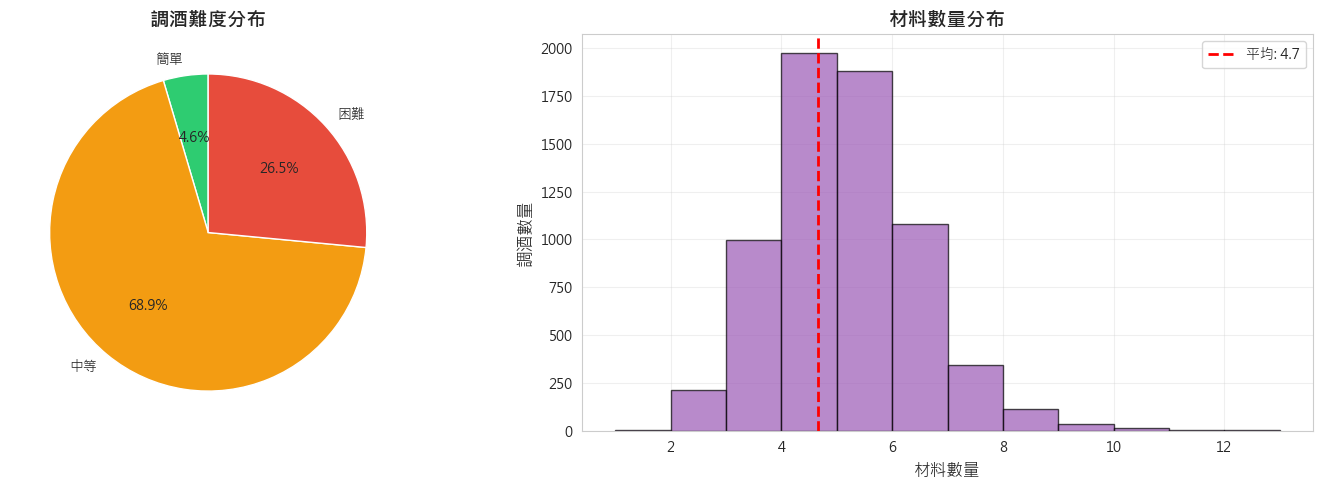

In [14]:
# 視覺化：難度分布與材料數量
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 難度分布圓餅圖
difficulty_counts = Counter(difficulty_data)
labels = [f"{d}\n({difficulty_counts[d]})" for d in ['easy', 'medium', 'hard']]
sizes = [difficulty_counts.get(d, 0) for d in ['easy', 'medium', 'hard']]
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].pie(sizes, labels=['簡單', '中等', '困難'], autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('調酒難度分布', fontsize=14, fontweight='bold')

# 材料數量分布
axes[1].hist(ingredient_counts, bins=range(1, max(ingredient_counts)+2), 
             color='#9b59b6', alpha=0.7, edgecolor='black')
axes[1].axvline(np.mean(ingredient_counts), color='red', linestyle='--', 
                linewidth=2, label=f'平均: {np.mean(ingredient_counts):.1f}')
axes[1].set_xlabel('材料數量', fontsize=12)
axes[1].set_ylabel('調酒數量', fontsize=12)
axes[1].set_title('材料數量分布', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

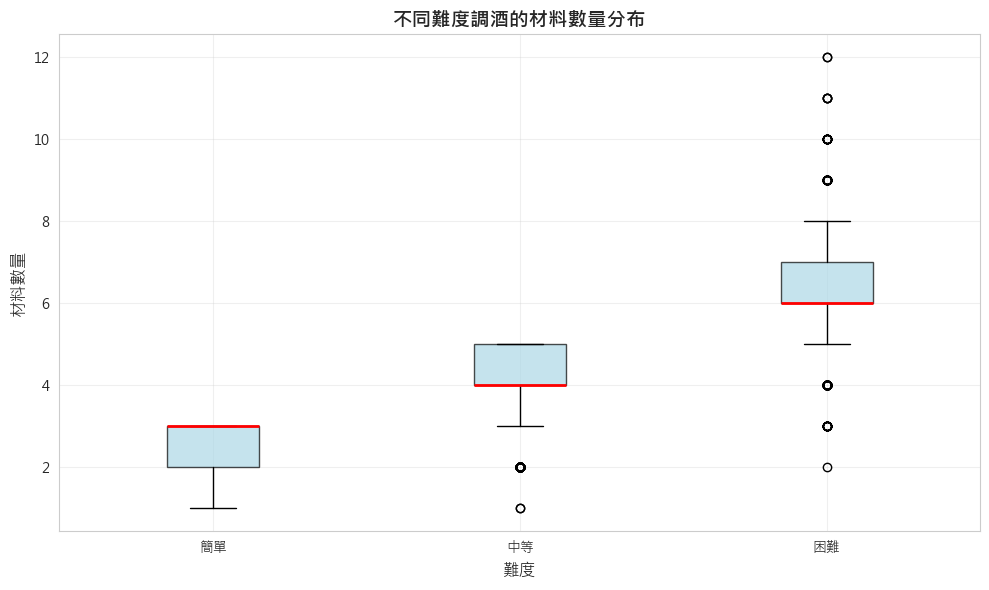


各難度平均材料數量:
  簡單: 2.68 種
  中等: 4.17 種
  困難: 6.27 種


In [15]:
# 箱型圖：難度 vs 材料數量
difficulty_ingredient_df = pd.DataFrame({
    'difficulty': difficulty_data,
    'ingredient_count': ingredient_counts
})

fig, ax = plt.subplots(figsize=(10, 6))
difficulty_order = ['easy', 'medium', 'hard']
difficulty_labels = ['簡單', '中等', '困難']

box_data = [difficulty_ingredient_df[difficulty_ingredient_df['difficulty'] == d]['ingredient_count'].values 
            for d in difficulty_order]

bp = ax.boxplot(box_data, labels=difficulty_labels, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))

ax.set_ylabel('材料數量', fontsize=12)
ax.set_xlabel('難度', fontsize=12)
ax.set_title('不同難度調酒的材料數量分布', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 統計驗證
print("\n各難度平均材料數量:")
for difficulty, label in zip(difficulty_order, difficulty_labels):
    data = difficulty_ingredient_df[difficulty_ingredient_df['difficulty'] == difficulty]['ingredient_count']
    print(f"  {label}: {data.mean():.2f} 種")

## 6. 營養與酒精指標分析

In [16]:
# 提取營養與酒精資料
calories = []
abv_values = []
nutrition_cocktails = []

for c in cocktails:
    cal = c.get('nutrition', {}).get('calories')
    abv = c.get('alcohol_metrics', {}).get('abv')
    
    if cal is not None:
        calories.append(cal)
        nutrition_cocktails.append(c.get('name', 'Unknown'))
    
    if abv is not None:
        abv_values.append(abv)

print(f"有卡路里資料: {len(calories)} 款")
print(f"有 ABV 資料: {len(abv_values)} 款")

if calories:
    print(f"\n卡路里統計:")
    print(f"  平均: {np.mean(calories):.0f} cal")
    print(f"  中位數: {np.median(calories):.0f} cal")
    print(f"  最高: {np.max(calories):.0f} cal")
    print(f"  最低: {np.min(calories):.0f} cal")
    
if abv_values:
    print(f"\nABV 統計:")
    print(f"  平均: {np.mean(abv_values):.1f}%")
    print(f"  中位數: {np.median(abv_values):.1f}%")
    print(f"  最高: {np.max(abv_values):.1f}%")
    print(f"  最低: {np.min(abv_values):.1f}%")

有卡路里資料: 5255 款
有 ABV 資料: 5618 款

卡路里統計:
  平均: 179 cal
  中位數: 177 cal
  最高: 2023 cal
  最低: 0 cal

ABV 統計:
  平均: 18.6%
  中位數: 18.2%
  最高: 66.1%
  最低: 0.0%



低卡調酒 (<150 cal): 1130 款 (21.5%)


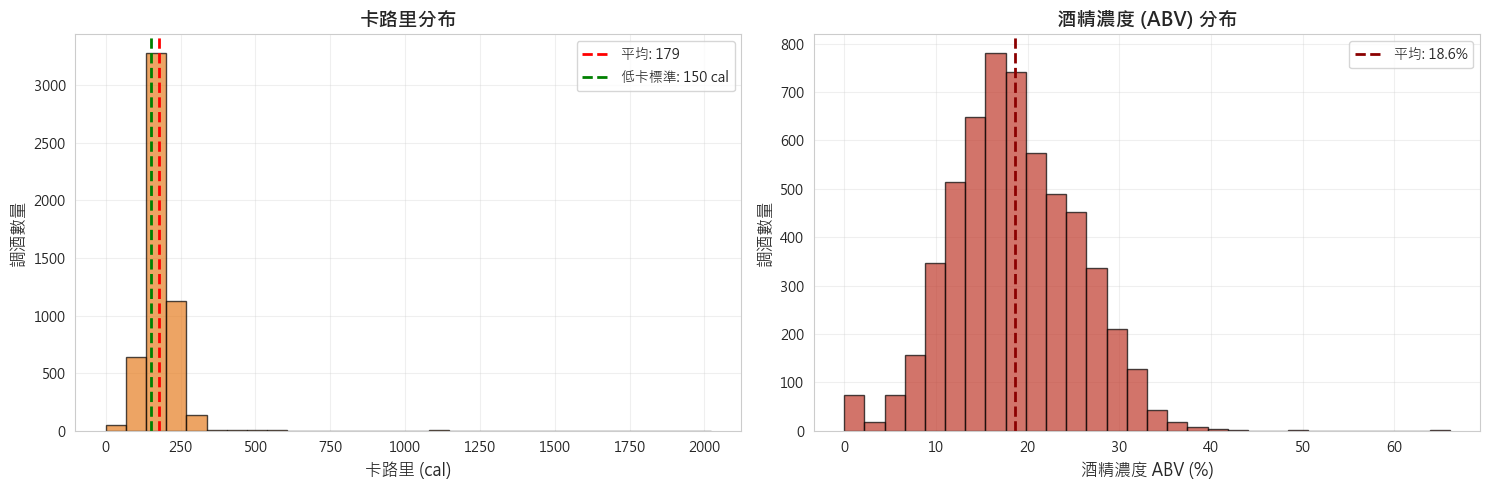

In [17]:
# 視覺化：營養與酒精指標
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 卡路里分布
if calories:
    axes[0].hist(calories, bins=30, color='#e67e22', alpha=0.7, edgecolor='black')
    axes[0].axvline(np.mean(calories), color='red', linestyle='--', linewidth=2, label=f'平均: {np.mean(calories):.0f}')
    axes[0].axvline(150, color='green', linestyle='--', linewidth=2, label='低卡標準: 150 cal')
    axes[0].set_xlabel('卡路里 (cal)', fontsize=12)
    axes[0].set_ylabel('調酒數量', fontsize=12)
    axes[0].set_title('卡路里分布', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 統計低卡調酒
    low_cal = sum(1 for c in calories if c < 150)
    print(f"\n低卡調酒 (<150 cal): {low_cal} 款 ({low_cal/len(calories)*100:.1f}%)")

# ABV 分布
if abv_values:
    axes[1].hist(abv_values, bins=30, color='#c0392b', alpha=0.7, edgecolor='black')
    axes[1].axvline(np.mean(abv_values), color='darkred', linestyle='--', linewidth=2, label=f'平均: {np.mean(abv_values):.1f}%')
    axes[1].set_xlabel('酒精濃度 ABV (%)', fontsize=12)
    axes[1].set_ylabel('調酒數量', fontsize=12)
    axes[1].set_title('酒精濃度 (ABV) 分布', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 分類分析

In [18]:
# 分類統計
categories = [c.get('category') for c in cocktails if c.get('category')]
category_counts = Counter(categories)

print(f"Unique 分類數量: {len(category_counts)}")
print(f"\nTop 20 分類:")
for i, (cat, count) in enumerate(category_counts.most_common(20), 1):
    percentage = count / total_cocktails * 100
    print(f"  {i:2d}. {cat:25s}: {count:4d} ({percentage:5.1f}%)")

Unique 分類數量: 17

Top 20 分類:
   1. Gin-based                : 1190 ( 17.9%)
   2. Other                    :  988 ( 14.8%)
   3. Whisky-based             :  878 ( 13.2%)
   4. Rum-based                :  826 ( 12.4%)
   5. Vodka-based              :  735 ( 11.0%)
   6. Brandy-based             :  528 (  7.9%)
   7. Martini                  :  337 (  5.1%)
   8. Tequila-based            :  289 (  4.3%)
   9. Sour                     :  249 (  3.7%)
  10. Frozen                   :  170 (  2.6%)
  11. Margarita                :  136 (  2.0%)
  12. Negroni                  :  117 (  1.8%)
  13. Punch                    :   88 (  1.3%)
  14. Shot                     :   54 (  0.8%)
  15. Mojito                   :   33 (  0.5%)
  16. Coffee                   :   30 (  0.5%)
  17. Tiki                     :   11 (  0.2%)


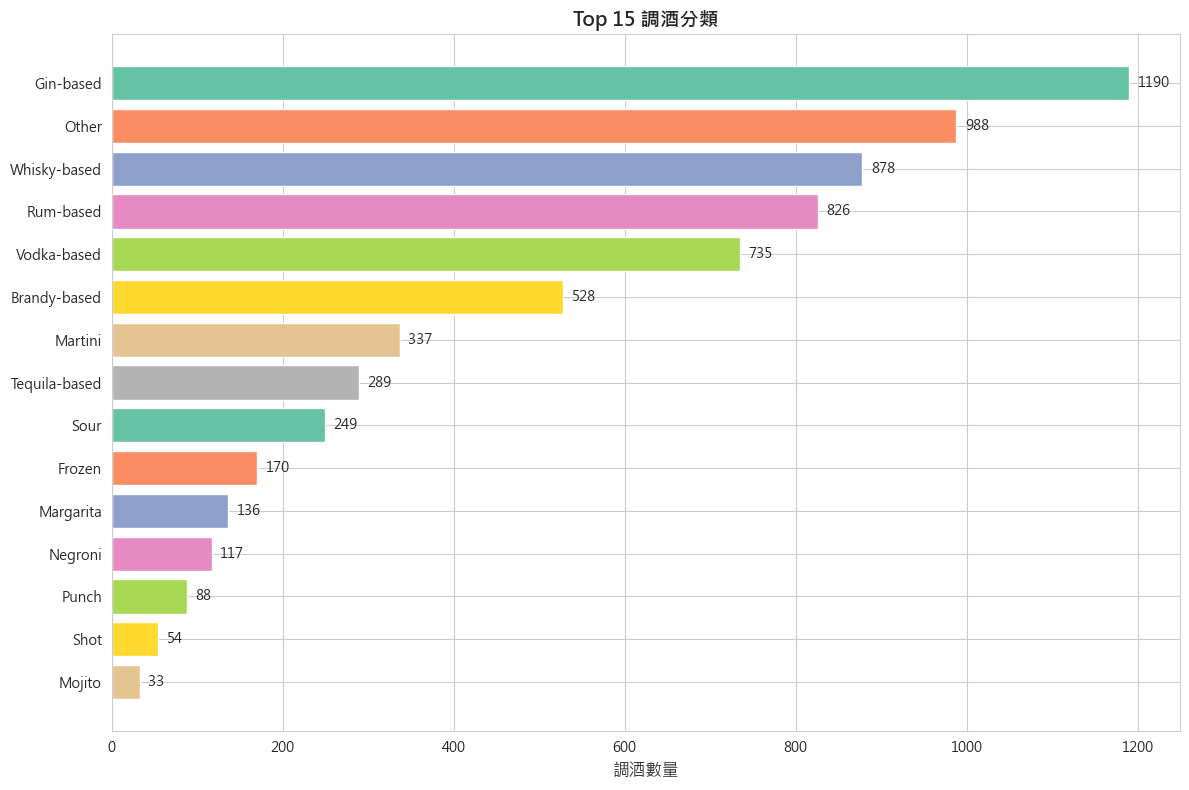

In [19]:
# 視覺化：Top 15 分類
top_15_categories = dict(category_counts.most_common(15))

fig, ax = plt.subplots(figsize=(12, 8))
categories = list(top_15_categories.keys())
counts = list(top_15_categories.values())

bars = ax.barh(range(len(categories)), counts, color=sns.color_palette('Set2', len(categories)))
ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories)
ax.set_xlabel('調酒數量', fontsize=12)
ax.set_title('Top 15 調酒分類', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# 添加數值標籤
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(count + 10, bar.get_y() + bar.get_height()/2, 
            f'{count}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 8. 標籤與材料分析

In [20]:
# 熱門標籤統計
tag_counts = Counter(all_tags)

print(f"Unique 標籤數量: {len(tag_counts)}")
print(f"標籤總使用次數: {len(all_tags)}")
print(f"平均每款調酒: {len(all_tags)/total_cocktails:.2f} 個標籤")
print(f"\nTop 20 熱門標籤:")
for i, (tag, count) in enumerate(tag_counts.most_common(20), 1):
    percentage = count / total_cocktails * 100
    print(f"  {i:2d}. {tag:15s}: {count:4d} ({percentage:5.1f}%)")

Unique 標籤數量: 15
標籤總使用次數: 12807
平均每款調酒: 1.92 個標籤

Top 20 熱門標籤:
   1. fruity         : 3786 ( 56.9%)
   2. gin            : 1594 ( 23.9%)
   3. strong         : 1434 ( 21.5%)
   4. rum            : 1222 ( 18.4%)
   5. whisky         : 1124 ( 16.9%)
   6. vodka          :  950 ( 14.3%)
   7. brandy         :  927 ( 13.9%)
   8. tequila        :  498 (  7.5%)
   9. creamy         :  323 (  4.9%)
  10. chocolate      :  310 (  4.7%)
  11. coffee         :  270 (  4.1%)
  12. minty          :  222 (  3.3%)
  13. light          :  137 (  2.1%)
  14. classic        :    5 (  0.1%)
  15. tiki           :    5 (  0.1%)


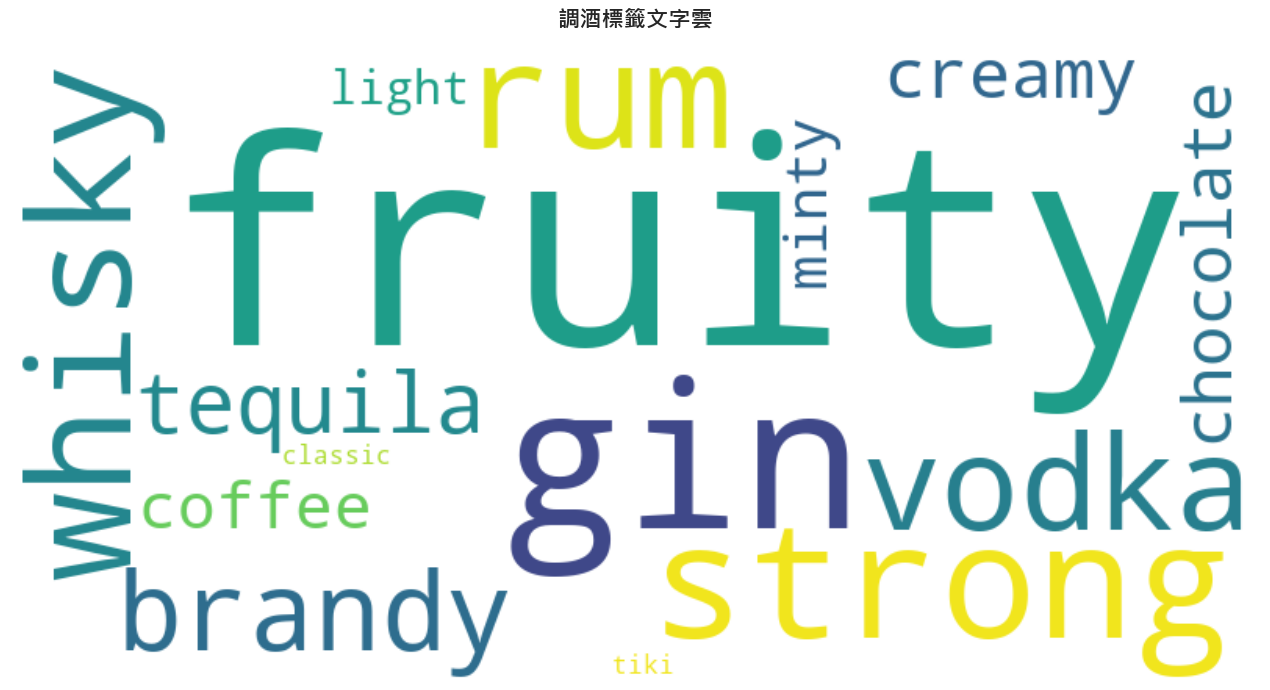

In [21]:
# 視覺化：標籤文字雲
if tag_counts:
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                         colormap='viridis', relative_scaling=0.5).generate_from_frequencies(tag_counts)
    
    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('調酒標籤文字雲', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

In [22]:
# 熱門材料統計
ingredient_counts = Counter(all_ingredients)

print(f"\nUnique 材料數量: {len(ingredient_counts)}")
print(f"材料總使用次數: {len(all_ingredients)}")
print(f"平均每款調酒: {len(all_ingredients)/total_cocktails:.2f} 種材料")
print(f"\nTop 30 熱門材料:")
for i, (ing, count) in enumerate(ingredient_counts.most_common(30), 1):
    percentage = count / total_cocktails * 100
    print(f"  {i:2d}. {ing:35s}: {count:4d} ({percentage:5.1f}%)")


Unique 材料數量: 943
材料總使用次數: 31010
平均每款調酒: 4.66 種材料

Top 30 熱門材料:
   1. lime juice                         : 1521 ( 22.8%)
   2. sugar syrup (2:1)                  : 1498 ( 22.5%)
   3. lemon juice                        : 1492 ( 22.4%)
   4. gin                                : 1131 ( 17.0%)
   5. aromatic bitters                   :  682 ( 10.2%)
   6. vodka                              :  649 (  9.7%)
   7. saline solution 4:1                :  583 (  8.8%)
   8. cognac (brandy)                    :  568 (  8.5%)
   9. rosso/sweet vermouth               :  550 (  8.3%)
  10. dry vermouth                       :  546 (  8.2%)
  11. light white rum                    :  500 (  7.5%)
  12. orange bitters                     :  485 (  7.3%)
  13. triple sec                         :  439 (  6.6%)
  14. orange juice                       :  436 (  6.5%)
  15. pineapple juice                    :  413 (  6.2%)
  16. bourbon whiskey                    :  403 (  6.1%)
  17. chilled water     

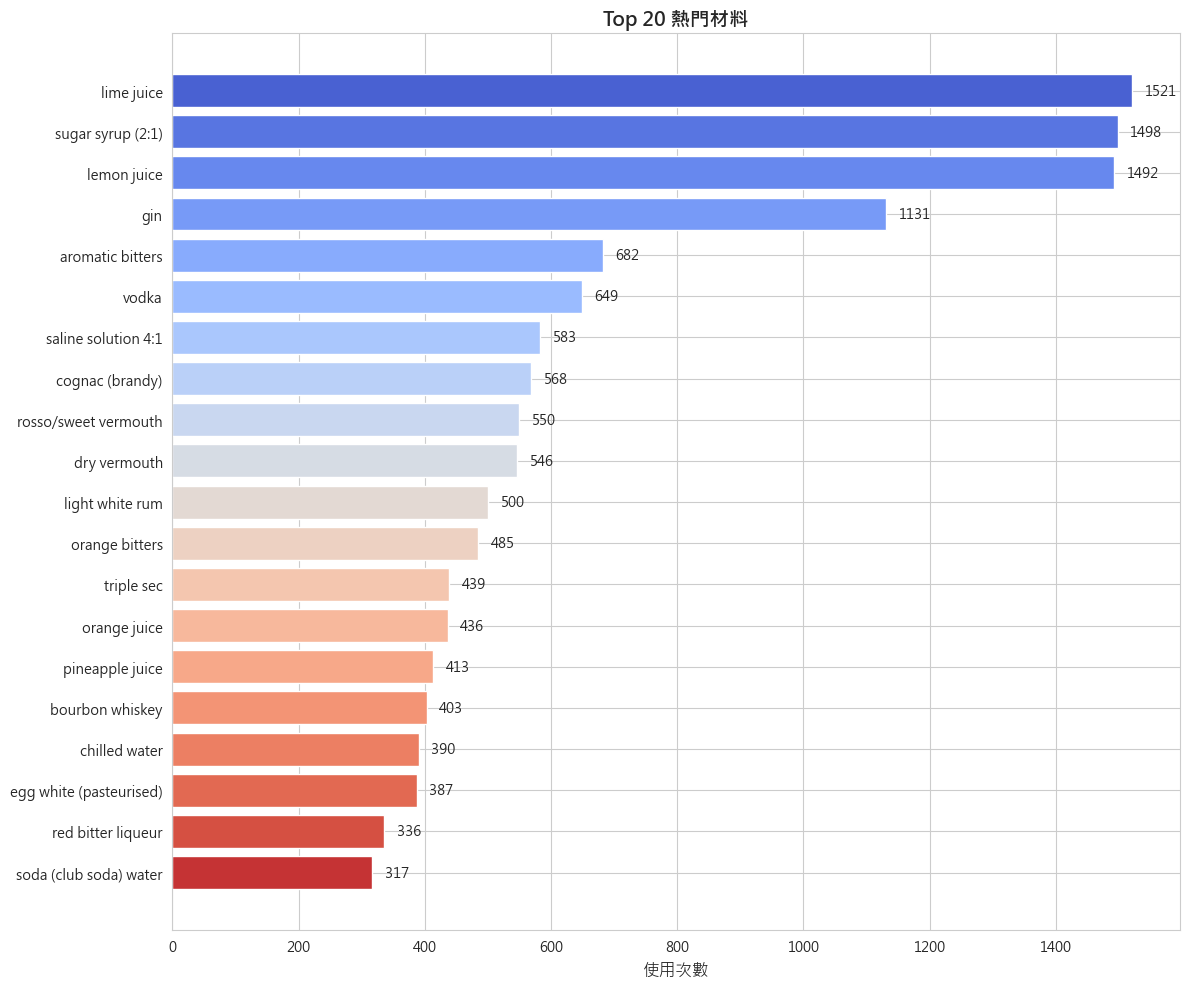

In [23]:
# 視覺化：Top 20 材料
top_20_ingredients = dict(ingredient_counts.most_common(20))

fig, ax = plt.subplots(figsize=(12, 10))
ingredients = list(top_20_ingredients.keys())
counts = list(top_20_ingredients.values())

bars = ax.barh(range(len(ingredients)), counts, color=sns.color_palette('coolwarm', len(ingredients)))
ax.set_yticks(range(len(ingredients)))
ax.set_yticklabels(ingredients)
ax.set_xlabel('使用次數', fontsize=12)
ax.set_title('Top 20 熱門材料', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# 添加數值標籤
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(count + 20, bar.get_y() + bar.get_height()/2, 
            f'{count}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 9. 綜合儀表板

In [24]:
# 建立綜合統計儀表板
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('資料完整度', '難度分布', 'Top 10 分類', '風味分布'),
    specs=[[{'type': 'bar'}, {'type': 'pie'}],
           [{'type': 'bar'}, {'type': 'scatter'}]]
)

# 1. 資料完整度
fields = list(completeness.keys())
percentages = [completeness[f] / total_cocktails * 100 for f in fields]
fig.add_trace(
    go.Bar(x=percentages, y=fields, orientation='h', name='完整度',
           marker_color='lightblue'),
    row=1, col=1
)

# 2. 難度分布
difficulty_labels = ['簡單', '中等', '困難']
difficulty_values = [difficulty_counts.get(d, 0) for d in ['easy', 'medium', 'hard']]
fig.add_trace(
    go.Pie(labels=difficulty_labels, values=difficulty_values, name='難度'),
    row=1, col=2
)

# 3. Top 10 分類
top_10_cat = dict(category_counts.most_common(10))
fig.add_trace(
    go.Bar(x=list(top_10_cat.values()), y=list(top_10_cat.keys()), 
           orientation='h', name='分類', marker_color='lightcoral'),
    row=2, col=1
)

# 4. 風味分布散點圖
if strength_values and sweetness_values:
    fig.add_trace(
        go.Scatter(x=strength_values, y=sweetness_values, mode='markers',
                  name='風味', marker=dict(size=5, opacity=0.6)),
        row=2, col=2
    )

fig.update_layout(height=800, showlegend=False, title_text="調酒資料綜合儀表板")
fig.show()

## 10. 資料洞察總結

In [25]:
# 產生洞察報告
print("="*60)
print("📊 調酒資料庫分析洞察報告")
print("="*60)

print(f"\n✅ 資料規模:")
print(f"   • 總調酒數: {total_cocktails:,} 款")
print(f"   • Unique 分類: {len(unique_categories)} 種")
print(f"   • Unique 材料: {len(unique_ingredients)} 種")
print(f"   • Unique 標籤: {len(unique_tags)} 個")
print(f"   • Unique 杯具: {len(unique_glasses)} 種")

if professional_ratings:
    print(f"\n⭐ 評分品質:")
    print(f"   • 平均專業評分: {np.mean(professional_ratings):.2f}/5")
    high_rated = sum(1 for r in professional_ratings if r >= 4.0)
    print(f"   • 高評分調酒 (≥4星): {high_rated} 款 ({high_rated/len(professional_ratings)*100:.1f}%)")

if strength_values:
    print(f"\n🌡️ 風味特徵:")
    print(f"   • 平均酒精強度: {np.mean(strength_values):.2f}/10")
    print(f"   • 平均甜度: {np.mean(sweetness_values):.2f}/10")

print(f"\n💪 難度分布:")
for difficulty, label in zip(['easy', 'medium', 'hard'], ['簡單', '中等', '困難']):
    count = difficulty_counts.get(difficulty, 0)
    total_diff = sum(difficulty_counts.values())
    print(f"   • {label}: {count} 款 ({count/total_diff*100:.1f}%)")

if calories:
    print(f"\n🍃 健康選擇:")
    low_cal = sum(1 for c in calories if c < 150)
    print(f"   • 低卡調酒 (<150 cal): {low_cal} 款 ({low_cal/len(calories)*100:.1f}%)")
    print(f"   • 平均卡路里: {np.mean(calories):.0f} cal")

print(f"\n🔝 熱門項目:")
print(f"   • 最熱門分類: {category_counts.most_common(1)[0][0]} ({category_counts.most_common(1)[0][1]} 款)")
print(f"   • 最常用材料: {ingredient_counts.most_common(1)[0][0]} (使用 {ingredient_counts.most_common(1)[0][1]} 次)")
print(f"   • 最熱門標籤: {tag_counts.most_common(1)[0][0]} (使用 {tag_counts.most_common(1)[0][1]} 次)")

print("\n" + "="*60)
print("✨ 分析完成！")
print("="*60)

📊 調酒資料庫分析洞察報告

✅ 資料規模:
   • 總調酒數: 6,659 款
   • Unique 分類: 17 種
   • Unique 材料: 943 種
   • Unique 標籤: 15 個
   • Unique 杯具: 203 種

⭐ 評分品質:
   • 平均專業評分: 4.14/5
   • 高評分調酒 (≥4星): 5372 款 (83.0%)

🌡️ 風味特徵:
   • 平均酒精強度: 6.82/10
   • 平均甜度: 6.40/10

💪 難度分布:
   • 簡單: 304 款 (4.6%)
   • 中等: 4590 款 (68.9%)
   • 困難: 1765 款 (26.5%)

🍃 健康選擇:
   • 低卡調酒 (<150 cal): 1130 款 (21.5%)
   • 平均卡路里: 179 cal

🔝 熱門項目:
   • 最熱門分類: Gin-based (1190 款)
   • 最常用材料: lime juice (使用 1521 次)
   • 最熱門標籤: fruity (使用 3786 次)

✨ 分析完成！
